In [1]:
  import pandas as pd 
  import numpy as np
  import matplotlib.pyplot as plt
  import pickle
  import json
  import shap

  # 加载模型
  with open('../data/processed/xgb_model.pkl', 'rb') as f:
      model = pickle.load(f)
  
  # 加载特征名
  with open('../data/processed/feature_names.json', 'r') as f:
      FEATURES = json.load(f)

  # 加载测试集和打分数据 
  X_test = pd.read_csv('../data/processed/X_test.csv')
  y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
  df     = pd.read_csv('../data/processed/customer_features_scored.csv')

  print(f'测试集: {X_test.shape}') 
  print(f'全量数据: {df.shape}')
  print(f'特征数: {len(FEATURES)}')

测试集: (11054, 29)
全量数据: (55267, 33)
特征数: 29


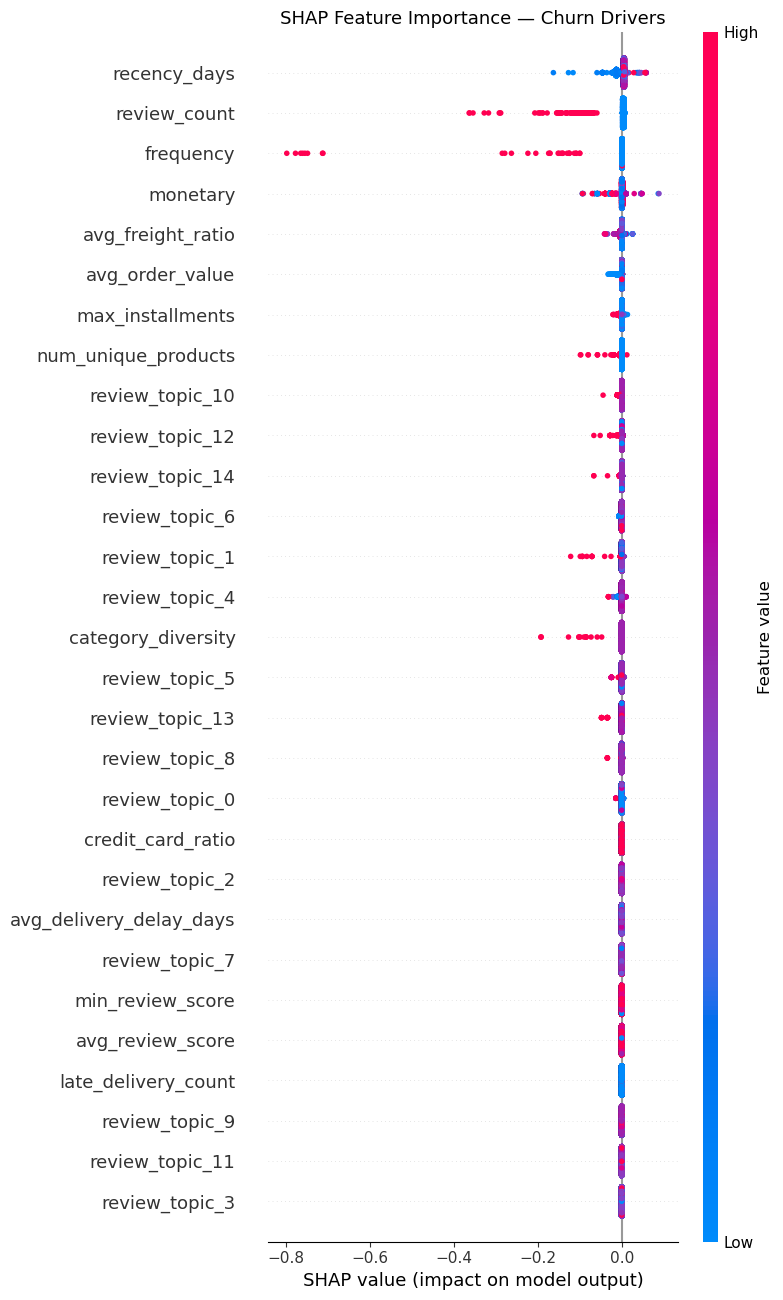

In [7]:
  explainer   = shap.TreeExplainer(model)
  shap_values = explainer.shap_values(X_test)

  # 只展示 top 15 特征，避免 TF-IDF 特征淹没 RFM
  plt.figure(figsize=(10, 7))   
  shap.summary_plot(
      shap_values, X_test,
      feature_names = FEATURES,
      max_display   = 29,
      show          = False
  )
  plt.title('SHAP Feature Importance — Churn Drivers', fontsize=13)
  plt.tight_layout()
  plt.savefig('../figures/shap_summary.png', dpi=150, bbox_inches='tight')
  plt.show()

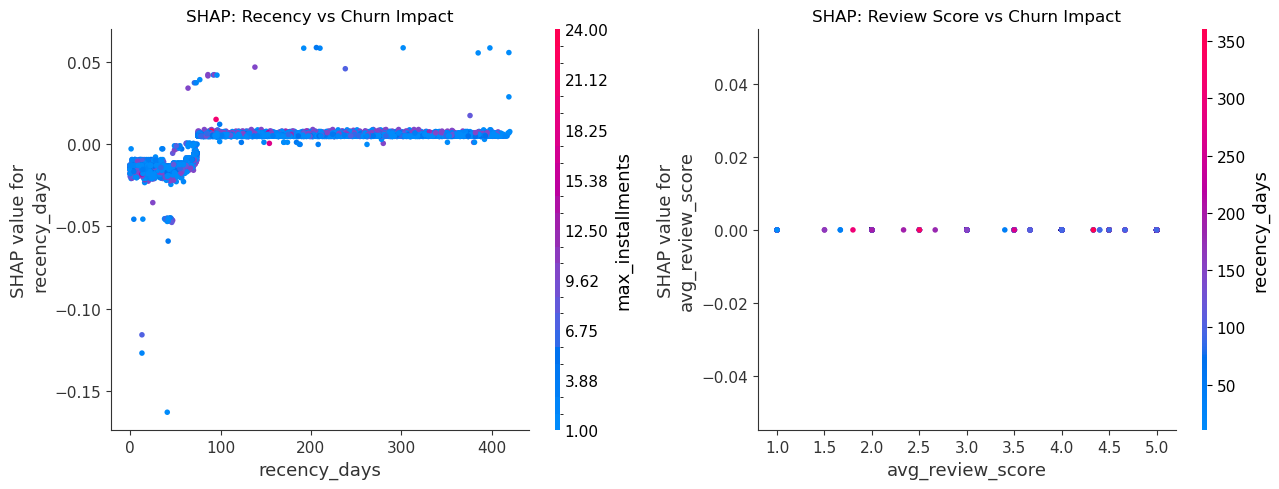

In [3]:
  fig, axes = plt.subplots(1, 2, figsize=(13, 5))

  # recency_days
  shap.dependence_plot(
      'recency_days', shap_values, X_test,
      feature_names=FEATURES, ax=axes[0], show=False
  )
  axes[0].set_title('SHAP: Recency vs Churn Impact')

  # avg_review_score
  shap.dependence_plot(
      'avg_review_score', shap_values, X_test,
      feature_names=FEATURES, ax=axes[1], show=False
  )
  axes[1].set_title('SHAP: Review Score vs Churn Impact')

  plt.tight_layout()  
  plt.savefig('../figures/shap_dependence.png', dpi=150, bbox_inches='tight')
  plt.show()

In [4]:

  # ── 业务假设 ──────────────────────────────────────────────
  CAMPAIGN_COST     = 5      # 每人优惠券成本（BRL）
  RETENTION_RATE    = 0.25   # 挽留成功率（行业 B2C 参考值）
  AVG_CLV           = df['monetary'].median()
  print(f'使用 CLV 中位数: BRL {AVG_CLV:.2f}')

  # ── 对不同投放规模模拟 ROI ────────────────────────────────
  results = [] 
  for pct in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
      threshold  = df['churn_prob'].quantile(1 - pct)
      targeted   = df[df['churn_prob'] >= threshold]
      n          = len(targeted)
      churners   = targeted['churned'].sum()
      recovered  = churners * RETENTION_RATE
      revenue    = recovered * AVG_CLV
      cost       = n * CAMPAIGN_COST
      net        = revenue - cost
      roi_ratio  = revenue / cost if cost > 0 else 0
  
      results.append({
          'Target %':          f'{pct:.0%}',
          'Customers':         n,
          'True Churners':     int(churners),
          'Revenue Recovered': round(revenue, 0),
          'Campaign Cost':     round(cost, 0),
          'Net ROI':           round(net, 0),
          'ROI Ratio':         round(roi_ratio, 2)
      })

  roi_df = pd.DataFrame(results)
  print(roi_df.to_string(index=False))
  roi_df.to_csv('../data/processed/roi_simulation.csv', index=False)

使用 CLV 中位数: BRL 106.17
Target %  Customers  True Churners  Revenue Recovered  Campaign Cost  Net ROI  ROI Ratio
      5%       3753           3731            99030.0          18765  80265.0       5.28
     10%      25763          25566           678586.0         128815 549771.0       5.27
     15%      25763          25566           678586.0         128815 549771.0       5.27
     20%      25763          25566           678586.0         128815 549771.0       5.27
     25%      25763          25566           678586.0         128815 549771.0       5.27
     30%      25763          25566           678586.0         128815 549771.0       5.27


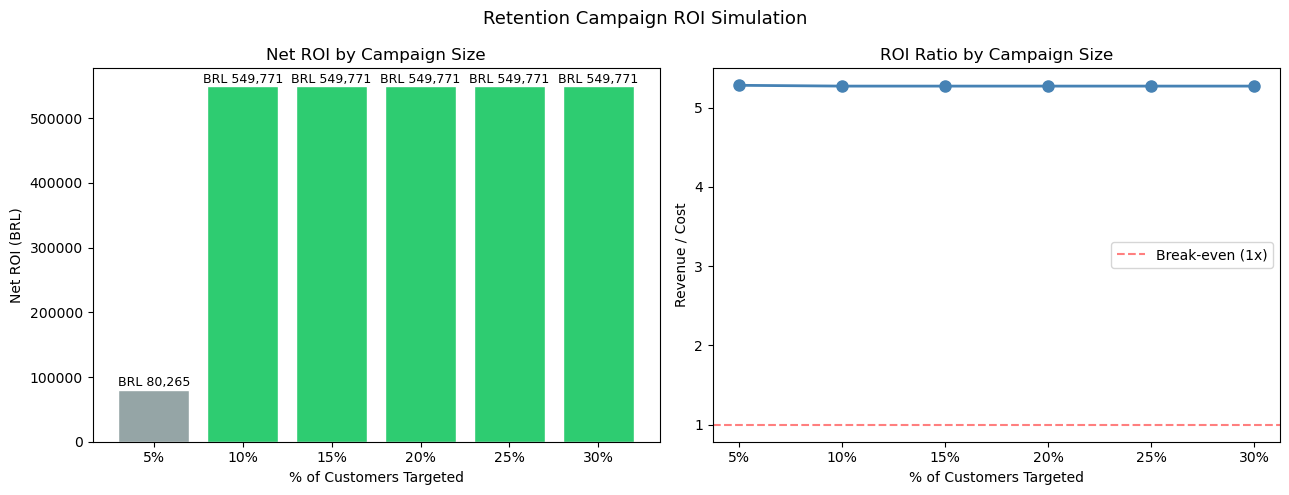

In [5]:
  fig, axes = plt.subplots(1, 2, figsize=(13, 5))
  
  pcts     = [r['Target %'] for r in results]
  net_rois = [r['Net ROI']  for r in results]
  ratios   = [r['ROI Ratio'] for r in results]

  # 左图：Net ROI by campaign size 
  bars = axes[0].bar(pcts, net_rois,
                     color=['#2ecc71' if v == max(net_rois) else '#95a5a6'
                            for v in net_rois],
                     edgecolor='white')
  axes[0].set_title('Net ROI by Campaign Size', fontsize=12)
  axes[0].set_xlabel('% of Customers Targeted')
  axes[0].set_ylabel('Net ROI (BRL)')
  for bar, val in zip(bars, net_rois):
      axes[0].text(bar.get_x() + bar.get_width()/2,
                   val + max(net_rois)*0.01,
                   f'BRL {val:,.0f}', ha='center', fontsize=9)
  
  # 右图：ROI Ratio（每1块钱成本带来多少收入）
  axes[1].plot(pcts, ratios, 'o-', color='steelblue', linewidth=2, markersize=8)
  axes[1].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Break-even (1x)')
  axes[1].set_title('ROI Ratio by Campaign Size', fontsize=12)
  axes[1].set_xlabel('% of Customers Targeted')
  axes[1].set_ylabel('Revenue / Cost')
  axes[1].legend()

  plt.suptitle('Retention Campaign ROI Simulation', fontsize=13)
  plt.tight_layout()  
  plt.savefig('../figures/roi_simulation.png', dpi=150)
  plt.show()